## Objectives for this project

This project applies k-means clustering to 35 years of US macroeconomic data to identify latent macro regimes, which are persistent environments characterised by distinct combinations of growth, inflation, monetary policy, and financial conditions. The goal is to test whether unsupervised learning can recover economically meaningful structure from raw data without imposing labels in advance.

The project also examines cross-asset (gold, equities, USD and bonds) behaviour across the different regimes to construct a toy regime-switching portfolio, benchmarked against the traditional, static 60/40 allocation. More traditional portfolio construction treats asset weights as fixed regardless of the macro environment but the 2022 rate shock demonstrated that bonds and equities can fall simultaneously, invalidating the diversification logic underlying most retail portfolios. Therefore, the project considers whether macro regime awareness can improve on static allocation in terms of risk-adjusted performance and drawdown protection.

## Setup

### Imports and module loading

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.data_loader import load_all, load_asset_classes, load_tbill
from src.features import engineer_features, standardise_features
from src.clustering import elbow_method,compute_silhouette, fit_clusters
from src.backtest import prepare_regime_data, asset_regime_performance, compute_allocations, run_backtest, compute_drawdown
from src.pca_analysis import run_pca, pca_clustering

## Data

All macroeconomic data is sourced from the Federal Reserve Economic Data (FRED) API, with equity market data from Yahoo Finance. The dataset spans January 1990 to present at monthly frequency as the start date is determined by VIX availability, which begins in 1990. Raw series are resampled to month-end to ensure consistent alignment across sources.

Eight features are engineered from ten raw series: Fed Funds Rate, CPI, industrial production, unemployment rate, 10-year and 2-year Treasury yields, BAA credit spread, DXY dollar index, VIX, and S&P 500 daily prices. The S&P 500 is used solely to compute realised volatility for the volatility risk premium feature and has been deliberately excluded as a direct clustering input to avoid circularity when regimes are later validated against equity returns.

In [4]:
df = engineer_features()
df.describe()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,real_rate,vol_risk_premium,dxy_monthly,treasury_spread,credit_spread,unemployment_rate,indust_prod,cpi
count,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,0.106082,19.198998,0.658757,1.026810,2.304048,5.675714,1.484548,2.622965
std,2.311883,7.378380,7.959645,0.919448,0.717384,1.764617,4.196013,1.545350
min,-8.372205,10.076952,-16.907846,-0.930000,1.300000,3.400000,-17.318282,-1.958761
25%,-1.181382,13.907043,-5.087427,0.250000,1.770000,4.300000,-0.322940,1.715620
50%,0.165633,17.436433,0.572642,0.955000,2.180000,5.300000,2.283781,2.587521
75%,1.978057,22.382107,6.077126,1.800000,2.682500,6.625000,3.769642,3.157086
max,4.113279,61.958330,22.796507,2.830000,6.100000,14.800000,16.552135,8.979361


## Feature Engineering

Eight feautures have been constructed to capture key dimensions of the macro cycle: growth, inflation, monetary policy, and financial conditions. Each feature is transformed to be stationary where necessary, so that k-means distances reflect meaningful economic differences rather than trending levels.
| Category | Feature | Transformation |
|---|---|---|
| Monetary Policy | Real Fed Funds Rate | Fed Funds minus CPI YoY |
| Risk Sentiment | Volatility Risk Premium | VIX minus annualised realised vol |
| Dollar | DXY Year-on-Year | Pct change vs 12 months prior |
| Yield Curve | Treasury Spread | 10y minus 2y yield, level |
| Credit | Credit Spread | BAA minus 10y yield, level |
| Labour Market | Unemployment Rate | Level |
| Growth | Industrial Production YoY | Pct change vs 12 months prior |
| Inflation | CPI Year-on-Year | Pct change vs 12 months prior |


The features and their transformations are illustrated below with NBER recession shading, showing how each variable behaves across the economic cycle.

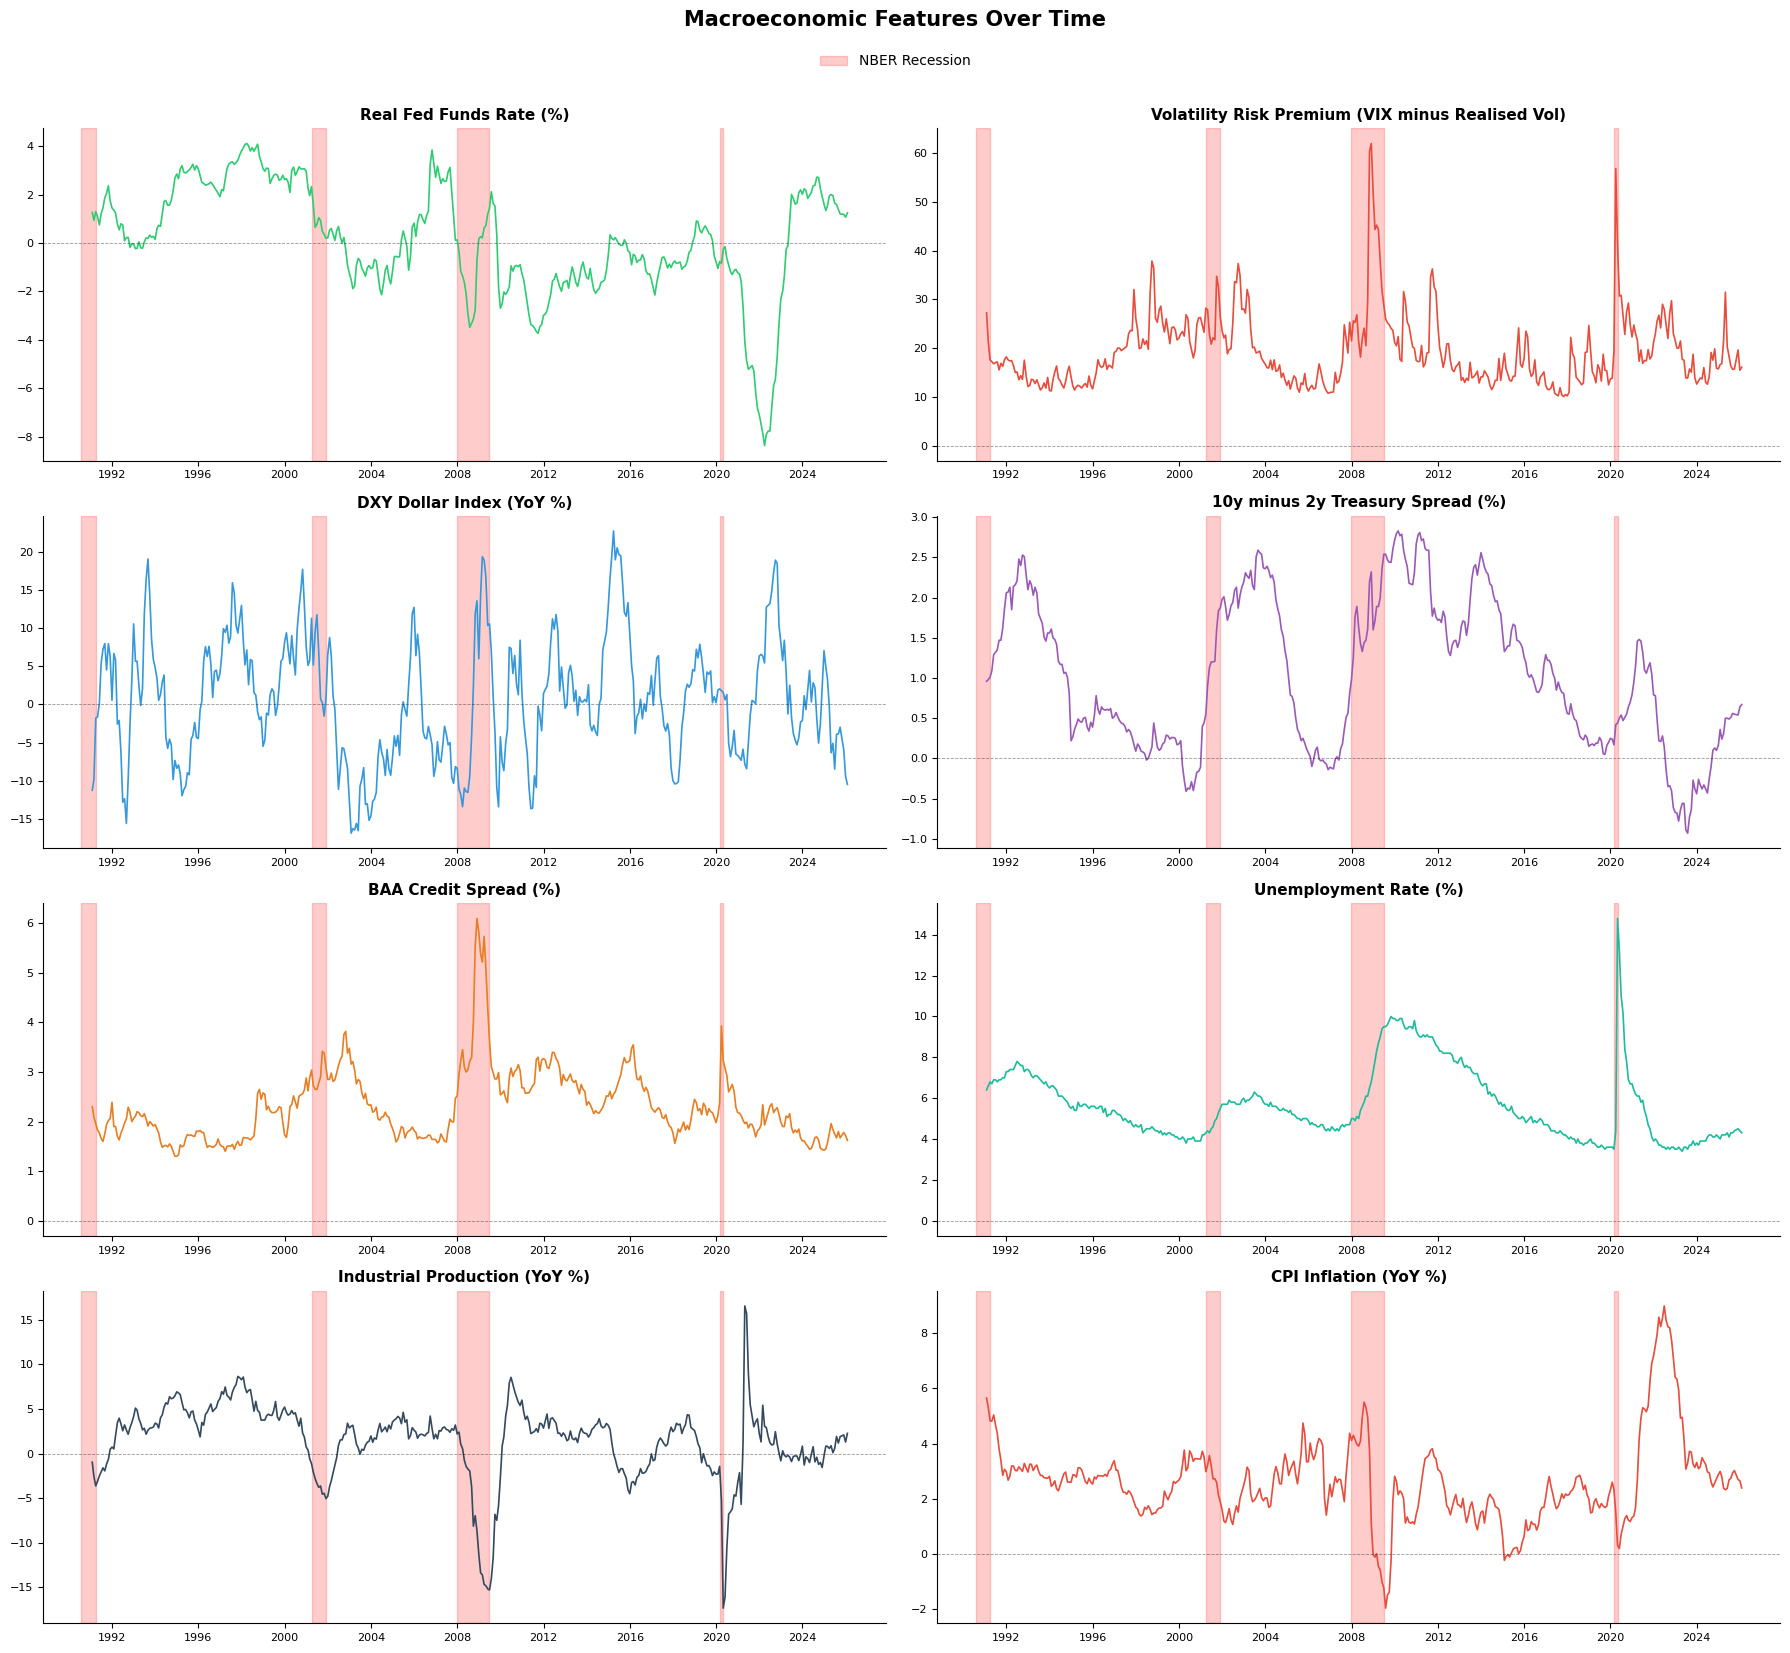

In [5]:
feature_titles = {
    'real_rate': 'Real Fed Funds Rate (%)',
    'vol_risk_premium': 'Volatility Risk Premium (VIX minus Realised Vol)',
    'dxy_monthly': 'DXY Dollar Index (YoY %)',
    'treasury_spread': '10y minus 2y Treasury Spread (%)',
    'credit_spread': 'BAA Credit Spread (%)',
    'unemployment_rate': 'Unemployment Rate (%)',
    'indust_prod': 'Industrial Production (YoY %)',
    'cpi': 'CPI Inflation (YoY %)'
}

feature_colors = {
    'real_rate': '#2ecc71',
    'vol_risk_premium': '#e74c3c',
    'dxy_monthly': '#3498db',
    'treasury_spread': '#9b59b6',
    'credit_spread': '#e67e22',
    'unemployment_rate': '#1abc9c',
    'indust_prod': '#34495e',
    'cpi': '#e74c3c'
}

recessions = [
    ('1990-07-31', '1991-03-31'),
    ('2001-03-31', '2001-11-30'),
    ('2007-12-31', '2009-06-30'),
    ('2020-02-29', '2020-04-30')
]

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, feat in zip(axes, feature_titles.keys()):
    ax.plot(df.index, df[feat], 
            color=feature_colors[feat], linewidth=1.2)
    
    for i, (start, end) in enumerate(recessions):
        ax.axvspan(start, end, alpha=0.2, color='red',
                   label='NBER Recession' if i == 0 else '')
    
    ax.axhline(y=0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
    ax.set_title(feature_titles[feat], fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

# Single recession legend across all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.01),
           ncol=1, fontsize=10, frameon=False)

plt.suptitle('Macroeconomic Features Over Time', 
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Patterns worth noting from the above plot:

**Leading vs lagging indicators**
Features combine a mixture of leading and lagging signals as both captures different phases of the growth cycle, for example unemployment is a lagging indicator as it sharply increases after the recession has already started , whereas the yield curve acts as a recession predictor, inverting before the 2001 and 2008 recessions.

**Credit spreads as a stress signal**
Credit spreads spike sharply during recessionary periods as investors become risk-averse so corporate yields rise while Treasury yields fall as capitalrotates to safety. 

**CPI heterogeneity across recessions**
CPI behaves differently across cycles. The 2008 recession showed a sharp spike then crash driven by oil prices, while 2020 barely registered before giving way to the largest inflation surge in 40 years. 

**Volatility risk premium spikes during stress**
Unsuprisingly, the VRP spikes dramatically during stress periods, peaking above 60 in 2008 as VIX surged in anticipation of volatility that was already materialising. The magnitude of the spike distinguishes Crisis regimes - a VRP above 40 is a reliable marker of severe market stress in this dataset.


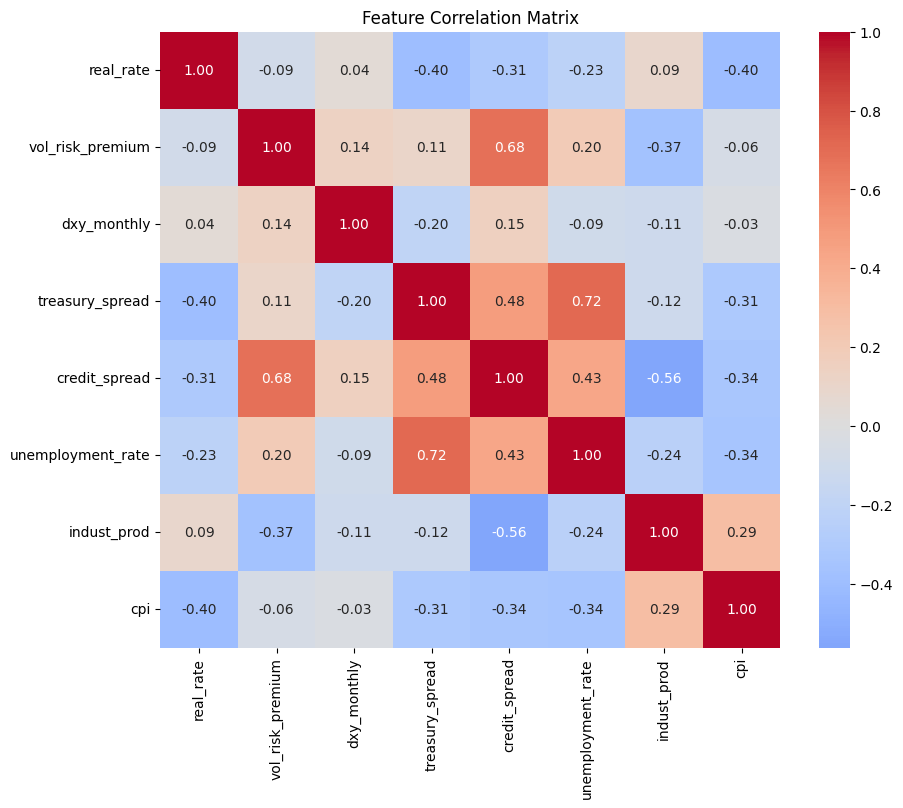

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

The correlation matrix reveals the strongest correlations between features: treasury spread with unemployment rate and volatility risk premium with credit spread. Volatility risk premium and credit spread both capture financial stress (from the credit and options market), whilst treasury spread and unemployment rate both reflect the recessionary phase of the cycle (unemployment rises and Fed cutting rates so yield curve steepens.

The presence of correlated features could be a concern as k-means operates on Euclidean distances, meaning correlated features effectively get double-counted and could distort the clustering toward dimensions with redundant signals. We address this in the robustness check section later using PCA.

In [7]:
# features are standardised for k-means
df_scaled, scaler = standardise_features(df)

## Choosing the number of clusters

k is a hyperparamter so to decide on the number of clusters to split our data, we use the elbow and silhouette methods.

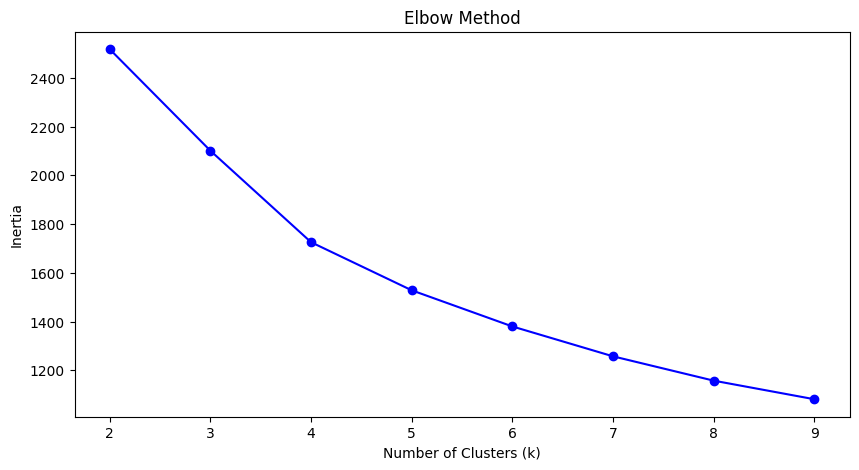

In [8]:
# elbow method
k_range, inertias = elbow_method (df_scaled)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.show()

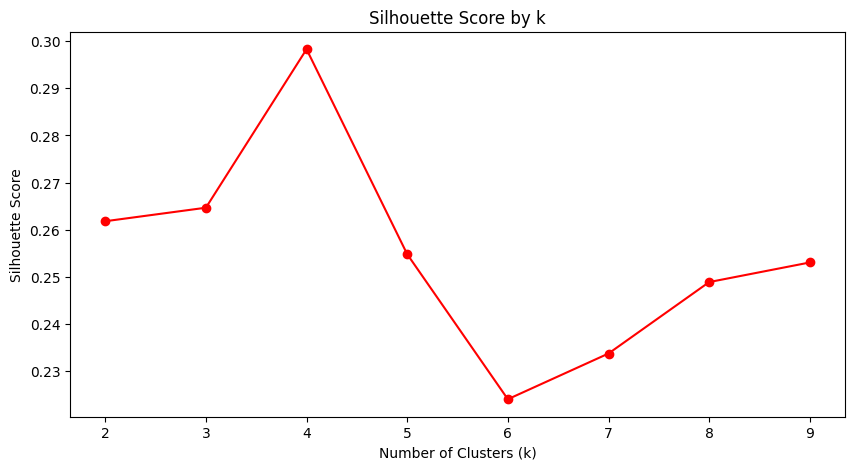

In [9]:
# silhouette method
k_range, scores = compute_silhouette(df_scaled)
plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.xticks(k_range)
plt.show()


The elbow plot shows inertia declining steeply from k=2 to k=4, with the rate of improvement flattening noticeably after k=4. This indicates that additional clusters beyond four provide diminishing returns in compactness. The silhouette score confirms this, peaking sharply at k=4 (0.30) before dropping at k=5 and k=6. Both methods converge on k=4 as the optimal number of clusters, which also maps cleanly onto four economically interpretable macro regimes. 

## Regime Identification

K-means clustering is applied to the standardised feature matrix to partition the 420 monthly observations into k=4 distinct macro regimes. The algorithm assigns each month to the cluster whose centroid it is closest to in eight-dimensional feature space, with no prior labels or economic assumptions imposed.

In [10]:
df, kmeans = fit_clusters(df,df_scaled, k=4)

In [11]:
print(df['regime'].value_counts())

# inspecting what months are in the regimes
print(df[df['regime'] == 2].index)
print(df[df['regime'] == 3].index)

regime
1    202
0    181
3     22
2     15
Name: count, dtype: int64
DatetimeIndex(['2008-10-31', '2008-11-30', '2008-12-31', '2009-01-31',
               '2009-02-28', '2009-03-31', '2009-04-30', '2009-05-31',
               '2009-06-30', '2009-07-31', '2009-08-31', '2020-03-31',
               '2020-04-30', '2020-05-31', '2020-06-30'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2021-05-31', '2021-06-30', '2021-07-31', '2021-08-31',
               '2021-09-30', '2021-10-31', '2021-11-30', '2021-12-31',
               '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
               '2022-09-30', '2022-10-31', '2022-11-30', '2022-12-31',
               '2023-01-31', '2023-02-28'],
              dtype='datetime64[us]', freq=None)


The majority of months fall into regimes 0 and 1, reflecting the normal state of the economy across most of the sample. Regimes 2 and 3 capture extreme macro environments: regime 2 identifies the 2008 financial crisis and COVID-2020, while regime 3 captures the 2021-2023 inflationary period.

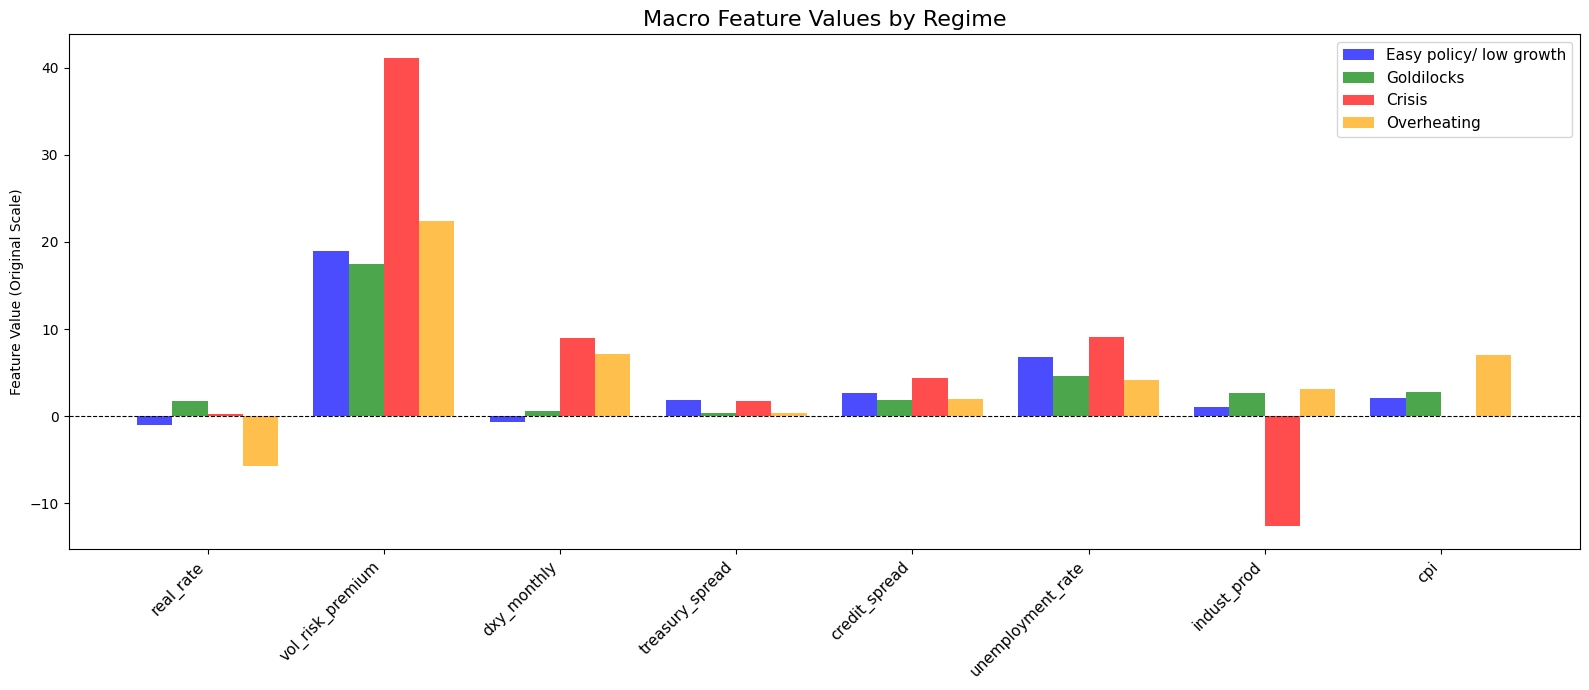

In [12]:
centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop(['regime'], axis=1).columns,
    index=['Easy policy/ low growth', 'Goldilocks', 'Crisis', 'Overheating']
)

# Plot each feature as a grouped bar chart
features = centroid_df.columns
n_features = len(features)
n_regimes = 4
x = np.arange(n_features)
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

colors = ['blue', 'green', 'red', 'orange']
for i, (regime, color) in enumerate(zip(centroid_df.index, colors)):
    ax.bar(x + i * width, centroid_df.loc[regime], width, 
           label=regime, color=color, alpha=0.7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Macro Feature Values by Regime', fontsize=16)
ax.set_ylabel('Feature Value (Original Scale)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The centroid chart reveals four economically distinct regimes: 
- Crisis (red) is characterised by a sharp spike in volatility risk premium and elevated credit spreads, showing markets are pricing extreme fear relative to realised volatility, alongside negative industrial production and near-zero CPI reflecting deflationary pressure from collapsed demand
- Goldilocks (green) shows positive real rates, healthy industrial production, low unemployment and tight credit spreads, indicative of a healthy expansion
- Easy Policy/Low Growth (blue) reflects the post-GFC decade: negative real rates as the Fed holds rates near zero, elevated unemployment still recovering, and a steep yield curve reflecting aggressive short-rate cuts
- Overheating (orange) is defined by deeply negative real rates despite high CPI, suggesting the Fed is behind the curve, alongside strong industrial production and a tight labour market

## Interpretation of Regimes

In [13]:
regime_labels = {0: 'Easy policy/ low growth', 1: 'Goldilocks', 2: 'Crisis', 3: 'Overheating'}
df['regime_label'] = df['regime'].map(regime_labels)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


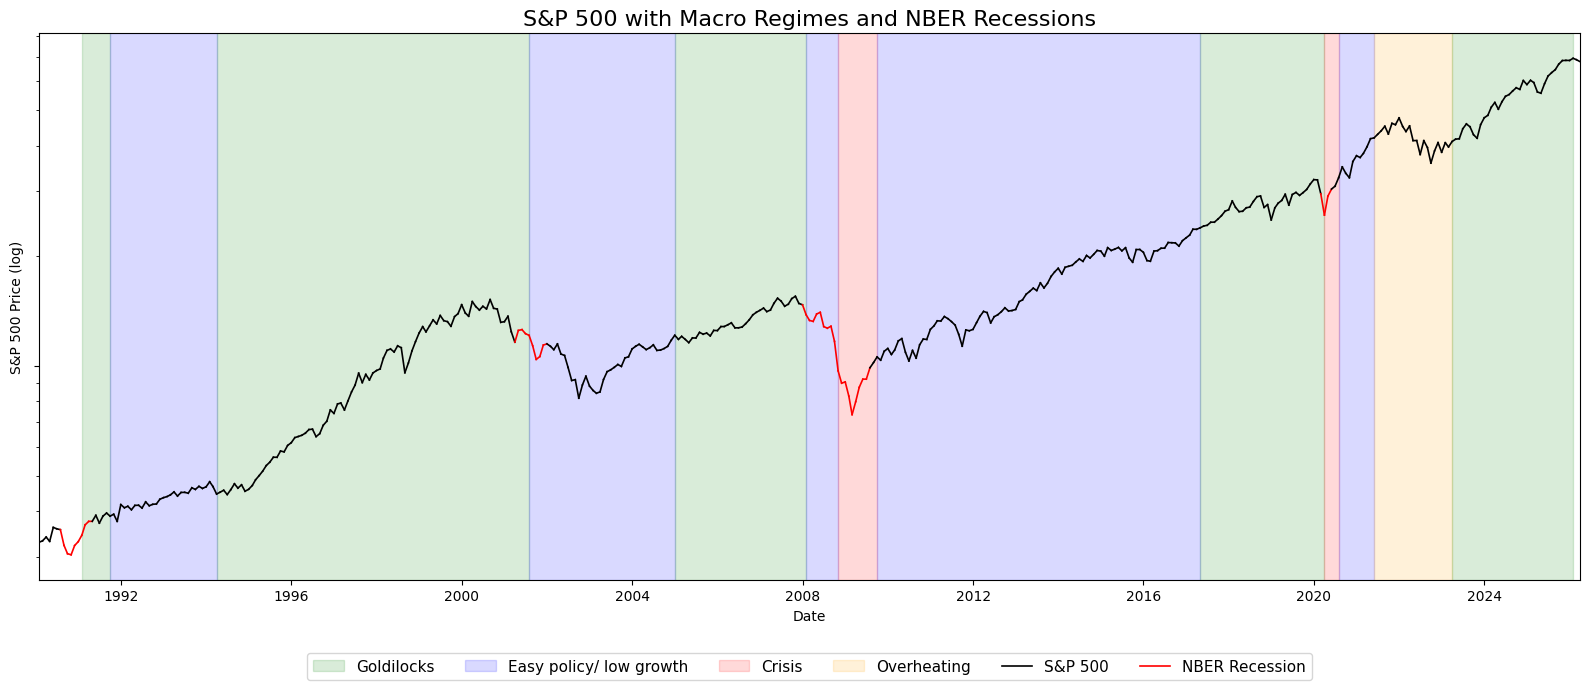

In [28]:
raw = load_all()
sp500_monthly = raw['sp500_daily'].resample('ME').last()

# adding the NBER recessions to see where the model tracks this
recessions = [
    ('1990-07-31', '1991-03-31'),
    ('2001-03-31', '2001-11-30'),
    ('2007-12-31', '2009-06-30'),
    ('2020-02-29', '2020-04-30')
]

regime_colors = {
    'Goldilocks': 'green',
    'Easy policy/ low growth': 'blue',
    'Crisis': 'red',
    'Overheating': 'orange'
}

fig, ax = plt.subplots(figsize=(16, 7))

# Shade regime periods
current_regime = df['regime_label'].iloc[0]
start_date = df.index[0]

for i in range(1, len(df)):
    if df['regime_label'].iloc[i] != current_regime or i == len(df) - 1:
        ax.axvspan(
            start_date,
            df.index[i],
            alpha=0.15,
            color=regime_colors[current_regime],
            label=current_regime
        )
        current_regime = df['regime_label'].iloc[i]
        start_date = df.index[i]

# Plot S&P 500 — different color during recessions
recession_periods = set()
for start, end in recessions:
    mask = (sp500_monthly.index >= start) & (sp500_monthly.index <= end)
    recession_periods.update(sp500_monthly.index[mask])

recession_label_added = False
normal_label_added = False

for i in range(len(sp500_monthly) - 1):
    x_vals = sp500_monthly.index[i:i+2]
    y_vals = sp500_monthly.values[i:i+2]
    in_recession = sp500_monthly.index[i] in recession_periods
    
    color = 'red' if in_recession else 'black'
    label = 'NBER Recession' if (in_recession and not recession_label_added) else \
            'S&P 500' if (not in_recession and not normal_label_added) else ''
    
    ax.plot(x_vals, y_vals, color=color, linewidth=1.2, zorder=5, label=label)
    
    if in_recession:
        recession_label_added = True
    else:
        normal_label_added = True

# Set x axis limits to data range exactly
ax.set_xlim(sp500_monthly.index[0], sp500_monthly.index[-1])

# Remove y ticks
ax.set_yticks([])
ax.set_yticklabels([])

# Legend below chart
handles, labels_list = ax.get_legend_handles_labels()
by_label = dict(zip(labels_list, handles))
ax.legend(by_label.values(), by_label.keys(), 
          loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=6, fontsize=11)

ax.set_title('S&P 500 with Macro Regimes and NBER Recessions', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('S&P 500 Price (log)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.NullFormatter()) # removes all labels on y axis
plt.tight_layout()
plt.savefig('../images/regime_graph.png', dpi=150, bbox_inches='tight')
plt.show()

### Golidlocks
Goldilocks periods represent the ideal macro environment with moderate growth, inflation close to target, positive real rates, and tight credit spreads. The model identifies the mid-1990s and mid-2000s expansions as the primary Goldilocks periods, alongside the post-pandemic recovery from 2023 onwards. Equity returns are strong and volatility is contained.

### Easy Growth
Easy Policy / Low Growth captures the prolonged post-GFC recovery from 2009 to 2021, which is the longest regime in the sample at over a decade. Growth is positive but subdued, the Fed holds rates near zero producing negative real rates, and the yield curve is steep. There are no dramatic events to point to. This regime reflects the absence of crisis rather than the presence of a catalyst and captures the 'new normal' of the post-financial crisis decade where unconventional monetary policy became the baseline.

### Crisis

Crisis periods are characterised by collapsing industrial production, spiking volatility and credit spreads, and deflationary pressure. The model groups 2008-09 and COVID-2020 together despite their different causes, correctly identifying them as sharing the same underlying macro structure. As the cross-asset analysis will show, this regime is the only one where gold and bonds simultaneously outperform equities.

### Overheating
The Overheating regime captures the 2021-2023 inflationary episode, characterised by deeply negative real rates as the Fed held policy loose despite surging CPI, alongside strong industrial production and a tight labour market. This is the regime where the 60/40 portfolio broke down most severely, as both equities and bonds sold off simultaneously when the Fed was forced to hike aggressively.

## Robustness Check - PCA

A key assumption underlying k-means clustering is that all features contribute independent information. When features are correlated, the distance calculations that determine cluster assignments are implicitly weighted toward the correlated dimensions.

Principal Component Analysis (PCA) addresses this by transforming the original correlated features into a set of orthogonal component: directions in the data that are by construction uncorrelated with each other. Each component captures a distinct dimension of variation, ranked by how much variance it explains.
PCA is used as a robustness check rather than as the primary clustering approach. If k-means is rerun on PCA components, instead of raw features, if we get the same regimes, the clusters are able to reflect macro structure robust to feature correlation.

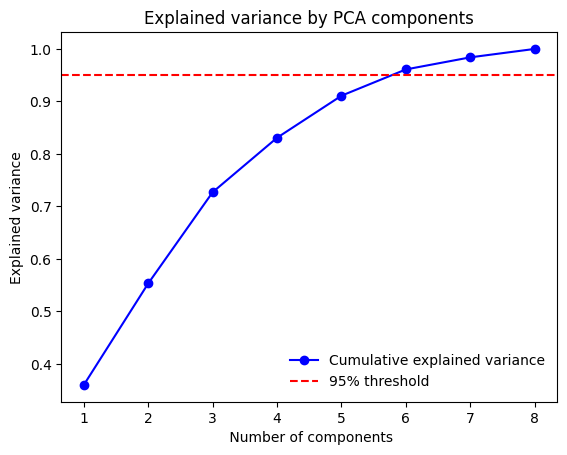

In [15]:
pca, n_components, explained_variance = run_pca(df_scaled)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-', label = "Cumulative explained variance")
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.title("Explained variance by PCA components")
plt.xlabel(" Number of components")
plt.ylabel("Explained variance")
plt.legend(fontsize=10, frameon=False)
plt.show()

Six components are required to explain 95% of variance across the eight features. This indicates the features capture relatively distinct dimensions of macro variation; if they were highly correlated, fewer components would suffice. The gradual curve with no sharp elbow suggests information is spread across multiple independent dimensions rather than concentrated in one or two dominant factors.

Adjusted Rand Score: 1.000


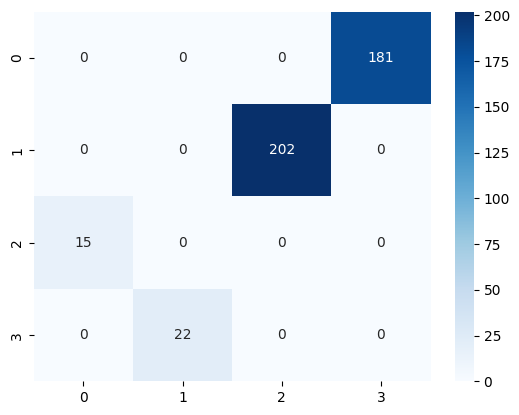

In [16]:
df = pca_clustering(n_components, df_scaled, df)

from sklearn.metrics import adjusted_rand_score, confusion_matrix
ari = adjusted_rand_score(df['regime'], df['regime_pca'])
cm = confusion_matrix(df['regime'], df['regime_pca'])
print(f"Adjusted Rand Score: {ari:.3f}")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

The Adjusted Rand Score of 1.0 indicates perfect agreement between the original and PCA-based clustering. Every month receives identical regime assignments regardless of whether raw correlated features or orthogonalised PCA components are used. This confirms the four regimes reflect genuine macro structure rather than artifacts of feature correlation. The confusion matrix shows each original cluster maps perfectly to exactly one PCA cluster, with the differences being purely label numbering.

## Cross-Asset Returns by Regime

With the 4 identified macroeconomic regime, we examine how different asset classes perform in each. We consider five asset classes: equities, bonds, gold, high yield credit, and the dollar and compute annualised return, volatility, and Sharpe ratio for each regime using the 3-month T-bill as the risk-free rate.
Note that TLT, GLD and HYD only have data from 2002, 2004 and 2007 respectively, so sample sizes vary across regimes.

In [17]:
asset_returns = load_asset_classes(df)
tbill_monthly = load_tbill()

results = asset_regime_performance(asset_returns, tbill_monthly)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


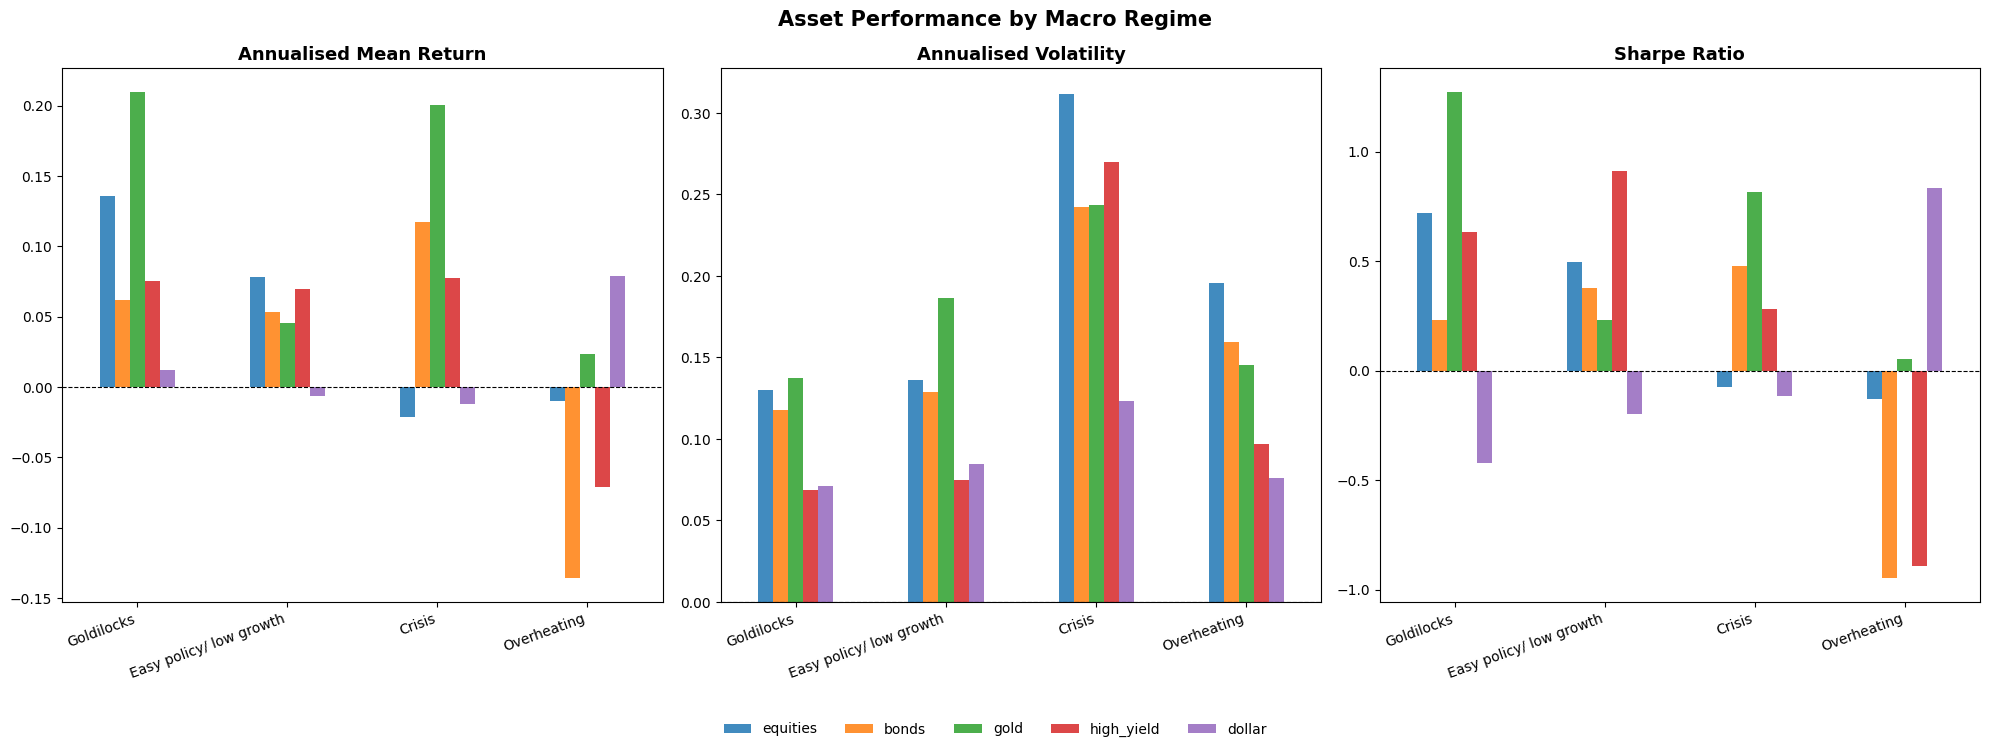

In [18]:
metrics = ['mean_return', 'volatility', 'sharpe']
metric_names = ['Annualised Mean Return', 'Annualised Volatility', 'Sharpe Ratio']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, metric, name in zip(axes, metrics, metric_names):
    table = pd.DataFrame({
        regime: results[regime][metric]
        for regime in results
    })
    table.T.plot(kind='bar', ax=ax, alpha=0.85)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticklabels(table.columns, rotation=20, ha='right')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.legend().set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=5, fontsize=10, frameon=False)

plt.suptitle('Asset Performance by Macro Regime', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

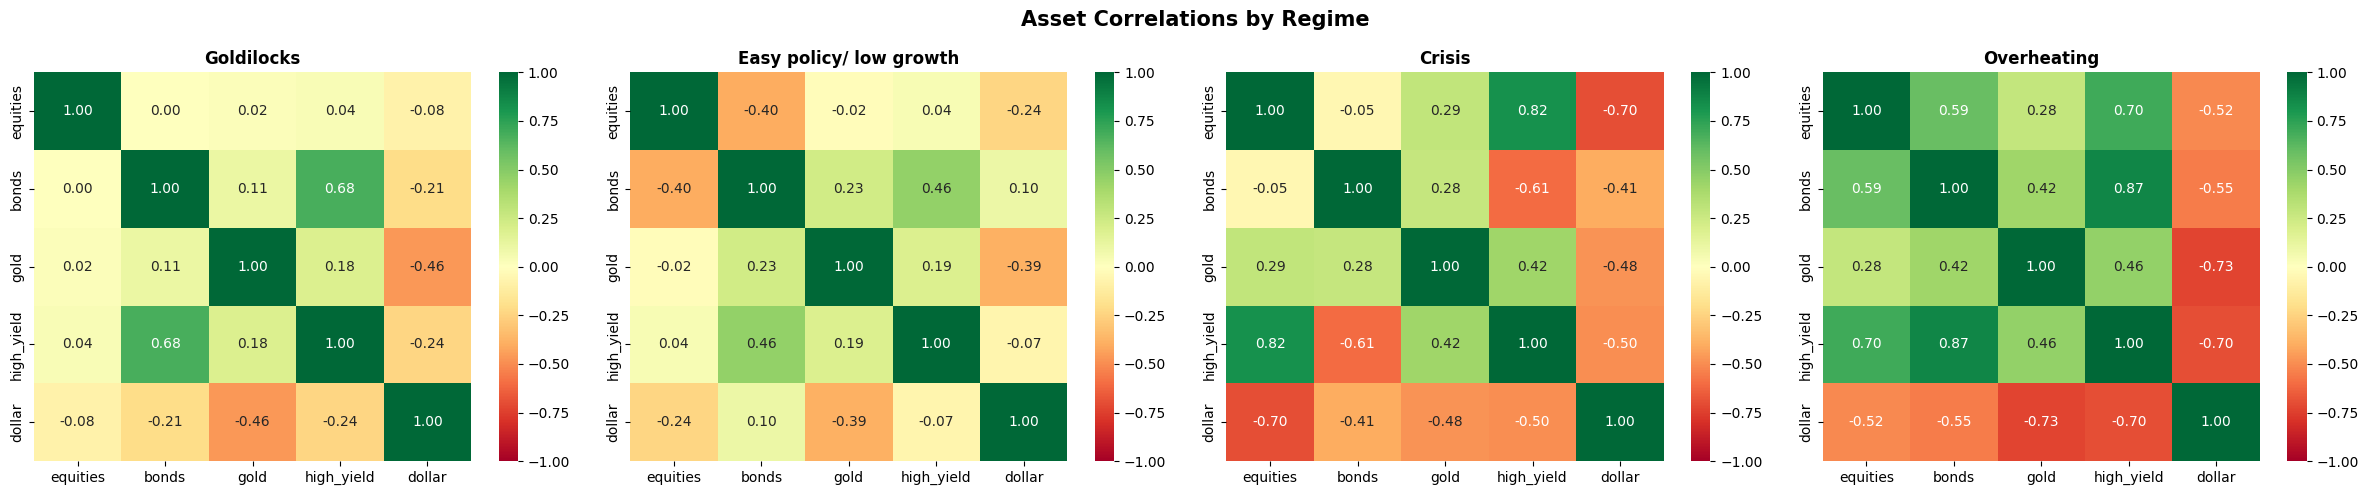

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, regime in zip(axes, results.keys()):
    sns.heatmap(results[regime]['correlation'],
                annot=True, fmt='.2f',
                cmap='RdYlGn', center=0,
                ax=ax, vmin=-1, vmax=1)
    ax.set_title(regime, fontsize=12, fontweight='bold')

plt.suptitle('Asset Correlations by Regime', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
for regime in results:
    sharpe = results[regime]['sharpe']
    best_asset = sharpe.idxmax()
    worst_asset = sharpe.idxmin()
    print(f"{regime}")
    print(f"  Best:  {best_asset} (Sharpe {sharpe[best_asset]:.2f})")
    print(f"  Worst: {worst_asset} (Sharpe {sharpe[worst_asset]:.2f})")
    print()

Goldilocks
  Best:  gold (Sharpe 1.27)
  Worst: dollar (Sharpe -0.42)

Easy policy/ low growth
  Best:  high_yield (Sharpe 0.91)
  Worst: dollar (Sharpe -0.20)

Crisis
  Best:  gold (Sharpe 0.82)
  Worst: dollar (Sharpe -0.11)

Overheating
  Best:  dollar (Sharpe 0.83)
  Worst: bonds (Sharpe -0.95)



Regime-conditional Sharpe ratios reveal differences in asset behaviour across macro environments:

**Goldilocks**

Gold leads with a Sharpe of 1.27, which is surprisingly strong for a risk-off asset in a benign environment, reflecting steady demand as inflation expectations normalise. Equities perform well but gold outperforms on a risk-adjusted basis. The dollar is the only negative-Sharpe asset, consistent with capital flowing away from safe havens toward risk assets during expansions.

**Easy Growth**

High yield dominates with a Sharpe of 0.91. This is a key feature of the zero rate environment where investors are forced to reach for yield. With the risk-free rate near zero, high yield credit offers attractive carry with contained default risk in a slow but stable growth environment. The dollar again underperforms as loose monetary policy weighs on the currency.

**Crisis**

Gold and bonds are the only meaningful stores of value during stress. Gold (0.82) and bonds (0.48) benefit from flight-to-safety flows as equities and high yield sell off. Suprisingly, the dollar is the worst performer despite its traditional safe-haven status, likely reflecting the specific nature of the 2008 crisis as a dollar-denominated financial shock.

**Overheating**

The dollar is the only asset with a positive Sharpe (0.83). Bonds are the worst performer (-0.95), destroyed by the rate shock. Crucially both equities and bonds are negative; this simultaneous breakdown of the 60/40 portfolio motivates the regime-switching approach covered in the next section.

## Regime-Switching Portfolio

We now construct a simple regime-switching portfolio, where for each month, we look at last month's detected regime and allocate accordingly.

Allocations are determined by Sharpe-weighted allocation, we allocate proportionally to each asset's regime-conditional Sharpe ratio, excluding assets with negative Sharpe entirely. Therefore, the portfolio automatically tilts toward whichever assets have historically performed best on a risk-adjusted basis in that macro environment.

Importantly, allocations are based on the previous month's regime rather than the current month. The one-month lag ensures the backtest reflects realistic implementation with no lookahead bias.

This is intentionally a **toy allocation**, where the primary goal is to illustrate whether regime awareness adds value, not to construct an optimised portfolio. Transaction costs, position limits, and execution constraints are all ignored.

In [21]:
# allocations computed by Sharpe ratio
allocations = compute_allocations(results)
for regime, weights in allocations.items():
    print(f"\n{regime}")
    for asset, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        print(f"  {asset:<15} {weight:.1%}")



Goldilocks
  gold            44.6%
  equities        25.2%
  high_yield      22.2%
  bonds           8.1%

Easy policy/ low growth
  high_yield      45.3%
  equities        24.6%
  bonds           18.7%
  gold            11.5%

Crisis
  gold            51.9%
  bonds           30.2%
  high_yield      17.9%

Overheating
  dollar          93.8%
  gold            6.2%


In [22]:
# Using a one month lag on regime assignment to ensure no lookahead bias
portfolio_df = run_backtest(asset_returns, allocations, use_lag=True)

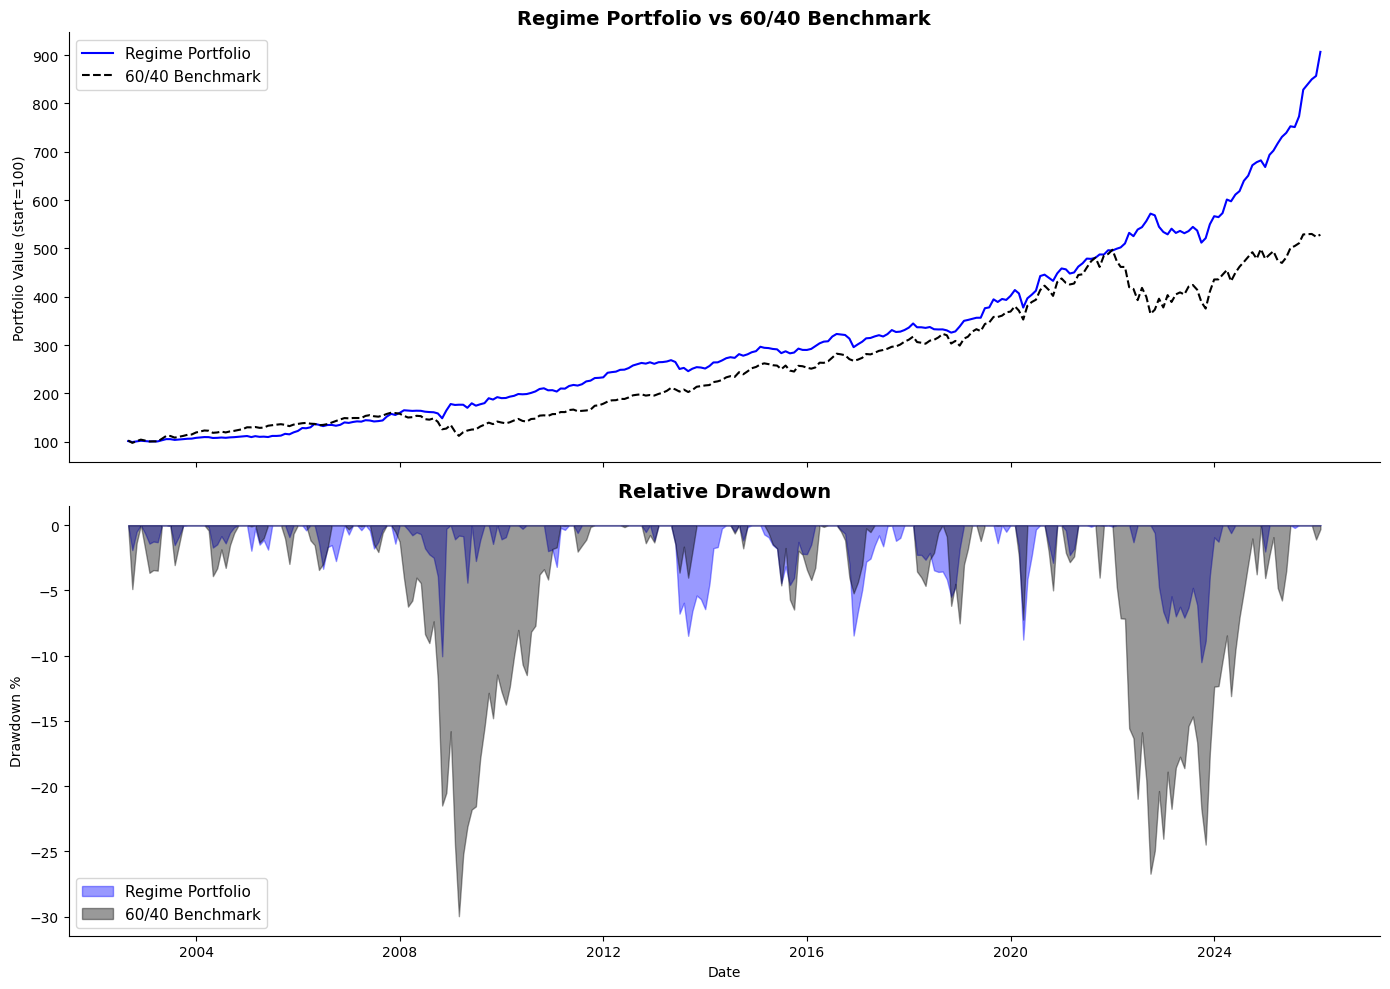

In [23]:
cumulative = (1 + portfolio_df).cumprod() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: cumulative returns
axes[0].plot(cumulative.index, cumulative['regime_portfolio'],
             color='blue', linewidth=1.5, label='Regime Portfolio')
axes[0].plot(cumulative.index, cumulative['sixty_forty'],
             color='black', linewidth=1.5, linestyle='--', label='60/40 Benchmark')
axes[0].set_ylabel('Portfolio Value (start=100)')
axes[0].set_title('Regime Portfolio vs 60/40 Benchmark', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bottom: drawdowns
regime_dd = compute_drawdown(portfolio_df['regime_portfolio'])
sixty_forty_dd = compute_drawdown(portfolio_df['sixty_forty'])

axes[1].fill_between(regime_dd.index, regime_dd, 0,
                     alpha=0.4, color='blue', label='Regime Portfolio')
axes[1].fill_between(sixty_forty_dd.index, sixty_forty_dd, 0,
                     alpha=0.4, color='black', label='60/40 Benchmark')
axes[1].set_ylabel('Drawdown %')
axes[1].set_xlabel('Date')
axes[1].set_title('Relative Drawdown', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Annualised metrics
for col, label in [('regime_portfolio', 'Regime Portfolio'), ('sixty_forty', '60/40')]:
    ret = portfolio_df[col].mean() * 12
    vol = portfolio_df[col].std() * (12**0.5)
    sharpe = (portfolio_df[col].mean() - tbill_monthly.reindex(
        portfolio_df.index).mean()) * 12 / vol
    max_dd = compute_drawdown(portfolio_df[col]).min()
    print(f"\n{label}")
    print(f"  Return:       {ret:.2%}")
    print(f"  Volatility:   {vol:.2%}")
    print(f"  Sharpe:       {sharpe:.2f}")
    print(f"  Max Drawdown: {max_dd:.2f}%")


Regime Portfolio
  Return:       9.73%
  Volatility:   7.47%
  Sharpe:       1.08
  Max Drawdown: -10.50%

60/40
  Return:       7.62%
  Volatility:   9.85%
  Sharpe:       0.60
  Max Drawdown: -29.96%


On an absolute returns basis, the model's regime-switching portfolio trails that of the 60/40 portfolio for the majority of the sample period but the portfolio demonstrates materially superior downside protection.

Maximum drawdown of -10.5% versus -30.0% for 60/40 reflects the model's successful rotation into dollar and gold during the 2021-2023 Overheating regime, where simultaneous equity and bond losses made traditional diversification ineffective.

On a risk-adjusted basis, the regime portfolio produces a Sharpe of 1.08 versus 0.60 for 60/40. The higher Sharpe is driven primarily by lower volatility (7.5% versus 9.9%) rather than higher returns; the portfolio takes on less risk per unit of return by avoiding the worst drawdown periods. This suggests that even a naive regime-aware allocation, without optimisation or leverage, meaningfully improves portfolio efficiency by reducing exposure during the most dangerous macro environments.

## Summary

K-means clustering on six macroeconomic features identifies four distinct regimes:  Goldilocks, Easy policy/ low growth , Crisis, and Overheating, each with economically interpretable characteristics consistent with established macro theory. The clustering is robust to dimensionality reduction, with an Adjusted Rand Score of 1.0 against PCA-based clustering confirming the regimes reflect genuine macro structure rather than feature correlation.

Cross-asset analysis validates the regime structure with Sharpe ratios varying significantly across regimes. Gold dominating in Crisis (0.82) and Goldilocks (1.27), the dollar is the only positive-Sharpe asset in Overheating (0.83), and bonds producing their worst risk-adjusted returns during Overheating (-0.95) consistent with the 2022 rate shock.

A regime-switching portfolio applying Sharpe-weighted allocations with a one-month implementation lag produces a Sharpe of 1.08 versus 0.60 for a static 60/40 benchmark, with maximum drawdown of -11% versus -30%. The drawdown improvement is the primary value-add - regime awareness significantly reduces tail risk even when absolute returns are comparable.